# Quantum-TurboQuant Measurement Spike

Question: does the four-stage compression pipeline (WHT → magnitude PolarQuant → phase quantization → QJL-analog 1-bit residual correction) produce a compression/fidelity asymmetry between **physical** statevectors (TFIM ground state, random MPS) and **Haar-random** statevectors at d = 1024?

Fidelity metric: $F = |\langle\psi|\hat\psi\rangle|^2$.  
Compression ratio: original bits ($2d \times 32$) / compressed bits.

Grid: 3 state classes × 4 pipeline configs × 3 bit budgets (2/2, 3/3, 4/4) × 20 samples = 720 measurements.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pipeline as pl
import states

FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

STATE_NAMES = ['haar', 'tfim', 'mps']
CONFIGS = ['wht', 'wht_mag', 'wht_mag_phase', 'full']
BIT_BUDGETS = [(2, 2), (3, 3), (4, 4)]
N_SAMPLES = 20

STATE_LABELS = {'haar': 'Haar-random', 'tfim': 'TFIM ground state', 'mps': 'Random MPS (χ=16)'}
CONFIG_LABELS = {
    'wht': 'WHT only',
    'wht_mag': '+ mag PolarQuant',
    'wht_mag_phase': '+ phase quant',
    'full': '+ QJL residual',
}
print('imports ok; numpy', np.__version__)

imports ok; numpy 2.4.4


In [2]:
records = []
t0 = time.time()
for state_name in STATE_NAMES:
    gen = states.STATE_GENERATORS[state_name]
    state_t0 = time.time()
    for sample_idx in range(N_SAMPLES):
        psi = gen(seed=sample_idx)
        for bits_mag, bits_phase in BIT_BUDGETS:
            for config in CONFIGS:
                # JL seed varies with sample so 'fresh random JL projections'
                # criterion is met for configs that use them.
                payload = pl.compress(
                    psi, config,
                    bits_mag=bits_mag,
                    bits_phase=bits_phase,
                    qjl_seed=10_000 * (1 + STATE_NAMES.index(state_name)) + sample_idx,
                )
                psi_hat = pl.decompress(payload)
                records.append({
                    'state_class': state_name,
                    'config': config,
                    'bits_per_magnitude': bits_mag,
                    'bits_per_phase': bits_phase,
                    'sample_idx': sample_idx,
                    'fidelity': pl.fidelity(psi, psi_hat),
                    'compression_ratio': pl.compression_ratio(payload),
                })
    print(f'{state_name:>5}: {time.time() - state_t0:6.1f}s')

df = pd.DataFrame(records)
df.to_csv('results.csv', index=False)
print(f'\nTotal: {len(df)} rows, {time.time() - t0:.1f}s; written to results.csv')
df.head()

 haar:    6.2s


 tfim:    6.1s


  mps:    6.4s

Total: 720 rows, 18.8s; written to results.csv


,state_class,config,bits_per_magnitude,bits_per_phase,sample_idx,fidelity,compression_ratio
0,haar,wht,2,2,0,1.000000,1.000000
1,haar,wht_mag,2,2,0,0.980801,1.875458
2,haar,wht_mag_phase,2,2,0,0.792064,15.515152
3,haar,full,2,2,0,0.840932,12.337349
4,haar,wht,3,3,0,1.000000,1.000000


In [3]:
agg = (df.groupby(['state_class', 'config', 'bits_per_magnitude', 'bits_per_phase'])
         .agg(fid_mean=('fidelity', 'mean'),
              fid_std=('fidelity', 'std'),
              ratio=('compression_ratio', 'mean'))
         .reset_index())

agg['fid_repr'] = agg.apply(lambda r: f"{r['fid_mean']:.4f} ± {r['fid_std']:.4f}", axis=1)
summary = agg.pivot_table(
    index=['state_class', 'config'],
    columns=['bits_per_magnitude'],
    values='fid_repr',
    aggfunc='first',
)
summary.columns = [f'{c}b mag/phase' for c in summary.columns]
# Reorder configs in pipeline order.
summary = summary.reindex(
    [(s, c) for s in STATE_NAMES for c in CONFIGS]
)
ratio_table = agg.pivot_table(
    index=['state_class', 'config'],
    columns=['bits_per_magnitude'],
    values='ratio',
    aggfunc='first',
).reindex([(s, c) for s in STATE_NAMES for c in CONFIGS])
ratio_table.columns = [f'{c}b ratio' for c in ratio_table.columns]

print('Mean fidelity ± std (n=20 per cell):')
print(summary.to_string())
print('\nMean compression ratio:')
print(ratio_table.round(2).to_string())

Mean fidelity ± std (n=20 per cell):
                              2b mag/phase     3b mag/phase     4b mag/phase
state_class config                                                          
haar        wht            1.0000 ± 0.0000  1.0000 ± 0.0000  1.0000 ± 0.0000
            wht_mag        0.9788 ± 0.0013  0.9939 ± 0.0005  0.9980 ± 0.0003
            wht_mag_phase  0.7947 ± 0.0067  0.9438 ± 0.0019  0.9853 ± 0.0007
            full           0.8425 ± 0.0060  0.9572 ± 0.0013  0.9889 ± 0.0005
tfim        wht            1.0000 ± 0.0000  1.0000 ± 0.0000  1.0000 ± 0.0000
            wht_mag        0.7456 ± 0.0000  0.7570 ± 0.0000  0.7574 ± 0.0000
            wht_mag_phase  0.7456 ± 0.0000  0.7570 ± 0.0000  0.7574 ± 0.0000
            full           0.7875 ± 0.0158  0.8042 ± 0.0073  0.8103 ± 0.0027
mps         wht            1.0000 ± 0.0000  1.0000 ± 0.0000  1.0000 ± 0.0000
            wht_mag        0.9674 ± 0.0059  0.9896 ± 0.0023  0.9955 ± 0.0018
            wht_mag_phase  0.7829 ± 0.0

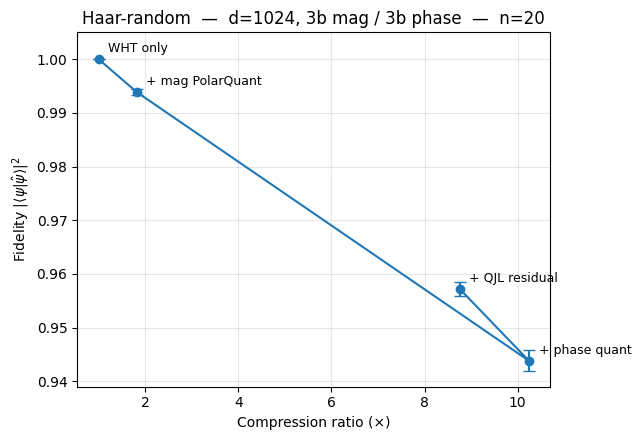

saved figures\haar_fidelity_vs_ratio.png


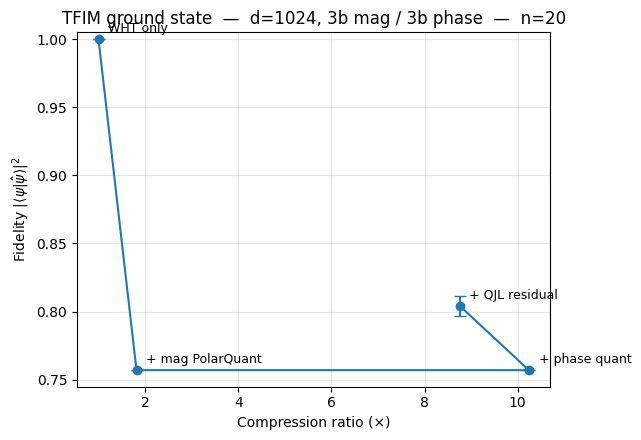

saved figures\tfim_fidelity_vs_ratio.png


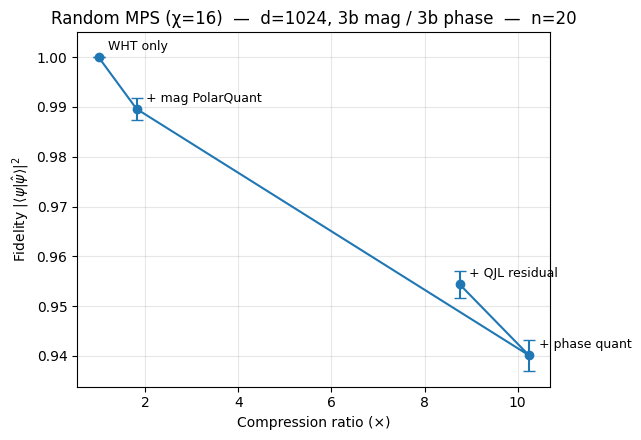

saved figures\mps_fidelity_vs_ratio.png


In [4]:
DEFAULT_BITS = 3  # plot at 3/3 default per brief

for state_name in STATE_NAMES:
    sub = df[(df['state_class'] == state_name) &
             (df['bits_per_magnitude'] == DEFAULT_BITS) &
             (df['bits_per_phase'] == DEFAULT_BITS)]
    g = (sub.groupby('config')
            .agg(fid_mean=('fidelity', 'mean'),
                 fid_std=('fidelity', 'std'),
                 ratio=('compression_ratio', 'mean'))
            .reindex(CONFIGS))
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    ax.errorbar(g['ratio'], g['fid_mean'], yerr=g['fid_std'],
                fmt='o-', capsize=4, lw=1.5)
    for cfg, row in g.iterrows():
        ax.annotate(CONFIG_LABELS[cfg], (row['ratio'], row['fid_mean']),
                    textcoords='offset points', xytext=(7, 5), fontsize=9)
    ax.set_xlabel('Compression ratio (×)')
    ax.set_ylabel('Fidelity $|\\langle\\psi|\\hat\\psi\\rangle|^2$')
    ax.set_title(f'{STATE_LABELS[state_name]}  —  d=1024, {DEFAULT_BITS}b mag / {DEFAULT_BITS}b phase  —  n=20')
    ax.grid(alpha=0.3)
    ax.set_ylim(top=1.005)
    fig.tight_layout()
    out_path = FIG_DIR / f'{state_name}_fidelity_vs_ratio.png'
    fig.savefig(out_path, dpi=140)
    plt.show()
    print('saved', out_path)

In [5]:
# Print a compact comparison so the asymmetry (if any) is visible at a glance.
for bits in [2, 3, 4]:
    print(f'\n=== {bits}b mag / {bits}b phase ===')
    for cfg in CONFIGS:
        line = f'{cfg:<14}'
        for s in STATE_NAMES:
            sub = df[(df['state_class'] == s) & (df['config'] == cfg) &
                     (df['bits_per_magnitude'] == bits) & (df['bits_per_phase'] == bits)]
            line += f'  {s}: F={sub["fidelity"].mean():.4f} (±{sub["fidelity"].std():.4f}) ratio={sub["compression_ratio"].mean():.2f}x'
        print(line)


=== 2b mag / 2b phase ===
wht             haar: F=1.0000 (±0.0000) ratio=1.00x  tfim: F=1.0000 (±0.0000) ratio=1.00x  mps: F=1.0000 (±0.0000) ratio=1.00x
wht_mag         haar: F=0.9788 (±0.0013) ratio=1.88x  tfim: F=0.7456 (±0.0000) ratio=1.88x  mps: F=0.9674 (±0.0059) ratio=1.88x
wht_mag_phase   haar: F=0.7947 (±0.0067) ratio=15.52x  tfim: F=0.7456 (±0.0000) ratio=15.52x  mps: F=0.7829 (±0.0065) ratio=15.52x
full            haar: F=0.8425 (±0.0060) ratio=12.34x  tfim: F=0.7875 (±0.0158) ratio=12.34x  mps: F=0.8328 (±0.0057) ratio=12.34x

=== 3b mag / 3b phase ===
wht             haar: F=1.0000 (±0.0000) ratio=1.00x  tfim: F=1.0000 (±0.0000) ratio=1.00x  mps: F=1.0000 (±0.0000) ratio=1.00x
wht_mag         haar: F=0.9939 (±0.0005) ratio=1.82x  tfim: F=0.7570 (±0.0000) ratio=1.82x  mps: F=0.9896 (±0.0023) ratio=1.82x
wht_mag_phase   haar: F=0.9438 (±0.0019) ratio=10.24x  tfim: F=0.7570 (±0.0000) ratio=10.24x  mps: F=0.9401 (±0.0032) ratio=10.24x
full            haar: F=0.9572 (±0.0013) 